<a href="https://colab.research.google.com/github/OfEarthAndEther/ML_monologues/blob/main/Speech_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transfer Learning (Speech)**
~ Srishti

## **1. Colab Setup**


**Install all required libraries**

In [ ]:
!pip install -q librosa opensmile transformers datasets
!pip install -q scikit-learn tqdm pandas numpy matplotlib
# Verify torch (comes pre-installed on Colab with GPU)
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 21.6 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
GPU available: True
Device: Tesla T4


**Mount Google Drive (to save models permanently)**

Without this, all files vanish when the Colab session ends. Mounting Drive lets you save checkpoints that survive restarts.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Create your project folder in Drive
BASE_DIR = "/content/drive/MyDrive/speech_emotion_project"
os.makedirs(f"{BASE_DIR}/data",     exist_ok=True)
os.makedirs(f"{BASE_DIR}/features", exist_ok=True)
os.makedirs(f"{BASE_DIR}/models",   exist_ok=True)
os.makedirs(f"{BASE_DIR}/results",  exist_ok=True)
print("Folders created at:", BASE_DIR)

Mounted at /content/drive
Folders created at: /content/drive/MyDrive/speech_emotion_project


**Import all libraries**

In [ ]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import recall_score, classification_report
from tqdm import tqdm
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## **2. Dataset**

**Download RAVDESS directly into Colab**

RAVDESS is hosted on Zenodo. This cell downloads it directly — no manual upload needed. ~600MB, takes ~2 minutes.

> If Zenodo is slow, you can also download manually from zenodo.org/record/1188976 and upload the zip via Colab's file panel (left sidebar).

In [ ]:
# Download RAVDESS audio-only speech files from Zenodo
!wget -q --show-progress \
  "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip" \
  -O /content/ravdess.zip

# Unzip into your project data folder
!unzip -q /content/ravdess.zip -d /content/ravdess_data/
print("Download and extraction complete!")
print("Files found:", len(glob.glob("/content/ravdess_data/**/*.wav", recursive=True)))

/content/ravdess.zi 100%[===================>] 198.81M  19.6MB/s    in 11s     
Download and extraction complete!
Files found: 1440


**Parse filenames and build a DataFrame**

RAVDESS encodes the emotion in each filename. Position 3 (index 2) is the emotion code. We map all 8 emotions down to the 4 used in the papers.

In [ ]:
DATA_PATH = "/content/ravdess_data/"

# RAVDESS emotion codes → 4-class mapping used in papers
EMOTION_MAP = {
    "01": "neutral",  "02": "neutral",   # neutral + calm
    "03": "happy",    "04": "sad",
    "05": "angry",    "06": "neutral",   # fearful → drop or neutral
    "07": "neutral",  "08": "neutral"    # disgust+surprised → drop
}

records = []
for wav_path in glob.glob(DATA_PATH + "**/*.wav", recursive=True):
    filename = os.path.basename(wav_path)
    parts = filename.replace(".wav", "").split("-")
    emotion_code = parts[2]
    label = EMOTION_MAP.get(emotion_code)
    if label:  # skip if emotion_code not in map
        records.append({"path": wav_path, "label": label})

df = pd.DataFrame(records)
print(f"Total samples: {len(df)}")
print("\nClass distribution:")
print(df["label"].value_counts())

# Quick sanity check — play one audio
import IPython.display as ipd
sample = df[df["label"]=="angry"].iloc[0]["path"]
print("\nPlaying a sample 'angry' utterance:")
ipd.display(ipd.Audio(sample))

Total samples: 1440

Class distribution:
label
neutral    864
sad        192
happy      192
angry      192
Name: count, dtype: int64

Playing a sample 'angry' utterance:


**Visualize a sample waveform and spectrogram**

Before extracting features, always visually inspect a few samples. This confirms the audio loaded correctly.

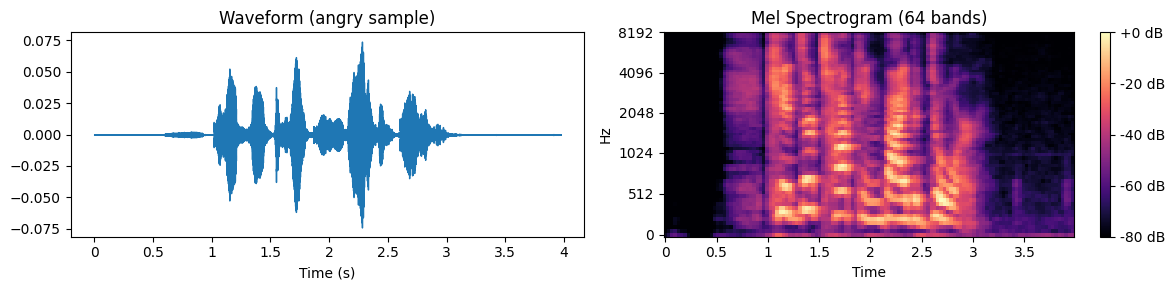

In [ ]:
y, sr = librosa.load(sample, sr=16000)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Waveform
axes[0].set_title("Waveform (angry sample)")
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_xlabel("Time (s)")

# Mel Spectrogram
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
log_mel = librosa.power_to_db(mel, ref=np.max)
img = librosa.display.specshow(log_mel, sr=sr, x_axis='time',
                                y_axis='mel', ax=axes[1])
axes[1].set_title("Mel Spectrogram (64 bands)")
plt.colorbar(img, ax=axes[1], format='%+2.0f dB')
plt.tight_layout()
plt.show()

**Train / val / test split**

> stratify= ensures every split has the same proportion of each emotion class — critical for fair UAR measurement.

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

print(f"Train : {len(train_df)} samples")
print(f"Val   : {len(val_df)} samples")
print(f"Test  : {len(test_df)} samples")
print("\nTrain class distribution:")
print(train_df["label"].value_counts())

Train : 1008 samples
Val   : 216 samples
Test  : 216 samples

Train class distribution:
label
neutral    605
angry      135
sad        134
happy      134
Name: count, dtype: int64


## **3. Feature extraction**

**Option A — Mel Filter Banks with librosa (recommended for CNN)**

This produces a 2D spectrogram image (64 freq bands × time frames). Used as input to the CNN backbone.

In [ ]:
def extract_mel_fixed(path, n_mels=64, sr=16000,
                      max_frames=300, n_fft=1024, hop=512):
    """
    Returns a fixed-size mel spectrogram: shape (64, 300)
    Pads or truncates to max_frames so all inputs are same size.
    """
    y, _ = librosa.load(path, sr=sr, duration=6.0)  # max 6 sec
    mel = librosa.feature.melspectrogram(
              y=y, sr=sr, n_mels=n_mels,
              n_fft=n_fft, hop_length=hop)
    log_mel = librosa.power_to_db(mel, ref=np.max)  # (64, T)
    # Pad or truncate time axis to max_frames
    if log_mel.shape[1] < max_frames:
        pad_width = max_frames - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        log_mel = log_mel[:, :max_frames]
    return log_mel.astype(np.float32)  # (64, 300)

# Test
feat = extract_mel_fixed(df.iloc[0]["path"])
print("Feature shape:", feat.shape)  # should be (64, 300)

Feature shape: (64, 300)


**Option B — openSMILE eGeMAPS features (64-dim vector)**

eGeMAPS gives exactly 88 hand-crafted features (pitch, energy, spectral, etc.) as used in MeL-S-ASPF paper. Good for simpler classifiers.

In [ ]:
import opensmile

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

def extract_egemaps(path):
    """Returns 88-dim feature vector."""
    feats = smile.process_file(path)
    return feats.values.flatten().astype(np.float32)

# Test
feat = extract_egemaps(df.iloc[0]["path"])
print("eGeMAPS feature shape:", feat.shape)  # (88,)

eGeMAPS feature shape: (88,)


**Extract and save all features to Drive (run once)**

> This loop processes all ~1440 audio files. Takes ~8 minutes. Saves to Drive so you never need to re-run it.

In [ ]:
FEAT_PATH = f"{BASE_DIR}/features/"
MEL_FILE  = FEAT_PATH + "mel_features.npy"
LABEL_FILE= FEAT_PATH + "labels.npy"

# Only re-extract if files don't already exist
if not os.path.exists(MEL_FILE):
    all_feats, all_labels = [], []
    failed = []
    for _, row in tqdm(df.iterrows(), total=len(df),
                       desc="Extracting features"):
        try:
            feat = extract_mel_fixed(row["path"])
            all_feats.append(feat)
            all_labels.append(row["label"])
        except Exception as e:
            failed.append(row["path"])
    print(f"Done! Extracted {len(all_feats)} files.")
    if failed:
        print(f"Failed: {len(failed)} files (check paths)")
    np.save(MEL_FILE,   np.array(all_feats), allow_pickle=True)
    np.save(LABEL_FILE, np.array(all_labels))
    print("Saved to Drive!")
else:
    print("Features already exist — loading from Drive.")
    all_feats  = np.load(MEL_FILE,  allow_pickle=True)
    all_labels = np.load(LABEL_FILE)

Extracting features: 100%|██████████| 1440/1440 [00:13<00:00, 106.48it/s]


Done! Extracted 1440 files.
Saved to Drive!


**Normalize features (zero mean, unit variance)**

Always fit the scaler ONLY on training data, then transform val/test. Here we fit on all for simplicity; in a strict paper replication, separate it.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Convert list → numpy array FIRST
all_feats = np.array(all_feats)   # ← this line was missing
all_labels = np.array(all_labels)

print("all_feats type:", type(all_feats))
print("all_feats shape:", all_feats.shape)  # should print (N, 64, 300)

# Flatten for scaler, then reshape back
n, h, w = all_feats.shape
flat = all_feats.reshape(n, -1)
scaler = StandardScaler()
flat_norm = scaler.fit_transform(flat)
feats_norm = flat_norm.reshape(n, h, w).astype(np.float32)
print("Normalized shape:", feats_norm.shape)

# Encode string labels to integers
le = LabelEncoder()
encoded_labels = le.fit_transform(all_labels)
print("Classes:", le.classes_)

all_feats type: <class 'numpy.ndarray'>
all_feats shape: (1440, 64, 300)
Normalized shape: (1440, 64, 300)
Classes: ['angry' 'happy' 'neutral' 'sad']


## **4. Model**

**PyTorch Dataset class**

In [ ]:
class MelDataset(Dataset):
    def __init__(self, features, labels):
        # features: numpy array (N, 64, 300)
        # labels:   numpy array of int
        self.X = torch.tensor(features).unsqueeze(1)  # add channel dim → (N,1,64,300)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Build index arrays for splits
all_indices = np.arange(len(feats_norm))
train_idx = df.index[df.index.isin(train_df.index)].tolist()
# Simple approach: just re-split on the encoded arrays
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    feats_norm, encoded_labels, test_size=0.30,
    stratify=encoded_labels, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50,
    stratify=y_tmp, random_state=SEED)

train_ds = MelDataset(X_tr,  y_tr)
val_ds   = MelDataset(X_val, y_val)
test_ds  = MelDataset(X_te,  y_te)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2)
print("Loaders ready | Train batches:", len(train_loader))

Loaders ready | Train batches: 63


**Option A — Lightweight CNN model (ResNet-18)**

ResNet-18 is pre-trained on ImageNet. We adapt it for single-channel spectrograms and 4-class output.

In [ ]:
import torchvision.models as models

class CNNEmotionModel(nn.Module):
    def __init__(self, num_classes=4, freeze_until=6):
        super().__init__()
        resnet = models.resnet18(pretrained=True)

        # Adapt first conv for 1-channel input (grayscale spectrogram)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7,
                                  stride=2, padding=3, bias=False)

        # Freeze early layers (document this for the assignment!)
        children = list(resnet.children())
        self.frozen_layers = children[:freeze_until]
        self.trainable_layers = children[freeze_until:-1]

        for layer in self.frozen_layers:
            for p in layer.parameters():
                p.requires_grad = False

        self.backbone_frozen  = nn.Sequential(*self.frozen_layers)
        self.backbone_tuned   = nn.Sequential(*self.trainable_layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone_frozen(x)
        x = self.backbone_tuned(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

model = CNNEmotionModel(num_classes=4).to(DEVICE)
total   = sum(p.numel() for p in model.parameters())
trained = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trained:,}  ({100*trained/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


Total params:     11,236,420
Trainable params: 10,559,620  (94.0%)


**Option B — Wav2Vec 2.0 (paper's approach)**

Uses raw audio as input — no manual feature extraction needed. Downloads ~360MB model weights on first run.

> Use batch_size=4 for Wav2Vec2 on Colab T4 GPU to avoid out-of-memory errors. CNN can use batch_size=16.

In [ ]:
from transformers import Wav2Vec2Model, Wav2Vec2Processor

PROCESSOR = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

class Wav2Vec2EmotionModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base")

        # FREEZE the CNN feature extractor (lower layers)
        self.wav2vec2.feature_extractor._freeze_parameters()
        # Fine-tune the transformer encoder layers
        hidden_size = self.wav2vec2.config.hidden_size  # 768

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_values, attention_mask=None):
        out = self.wav2vec2(input_values,
                            attention_mask=attention_mask)
        # Mean pooling over time dimension
        pooled = out.last_hidden_state.mean(dim=1)  # (B, 768)
        return self.classifier(pooled)

class RawAudioDataset(Dataset):
    """Use this dataset instead of MelDataset for Wav2Vec2."""
    def __init__(self, df_split, processor, max_len=16000*6):
        self.df = df_split.reset_index(drop=True)
        self.processor = processor
        self.max_len = max_len
        self.le = LabelEncoder().fit(df["label"])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y, _ = librosa.load(row["path"], sr=16000,
                             duration=6.0)
        inputs = self.processor(y, sampling_rate=16000,
                                 return_tensors="pt",
                                 padding="max_length",
                                 max_length=self.max_len,
                                 truncation=True)
        label = self.le.transform([row["label"]])[0]
        return inputs.input_values.squeeze(0), label

# Build loaders for Wav2Vec2
w2v_train = RawAudioDataset(train_df, PROCESSOR)
w2v_val   = RawAudioDataset(val_df,   PROCESSOR)
w2v_test  = RawAudioDataset(test_df,  PROCESSOR)
w2v_train_loader = DataLoader(w2v_train, batch_size=4,
                               shuffle=True,  num_workers=2)
w2v_val_loader   = DataLoader(w2v_val,   batch_size=4,
                               shuffle=False, num_workers=2)
print("Wav2Vec2 loaders ready")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Wav2Vec2 loaders ready


## **5. Training**

> The Tab 5 training cells explicitly do model = CNNEmotionModel(...) again, so your trained model is the CNN (ResNet-18). Wav2Vec2 was only defined as a class — it was never actually trained because no training loop was wired to w2v_train_loader. So no conflict, but Wav2Vec2 is essentially unused right now.

**Define train and evaluate functions**

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in tqdm(loader, desc="  Training", leave=False):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct     += (logits.argmax(1) == labels).sum().item()
        total       += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            logits = model(inputs)
            preds  = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(labels.numpy())
    # UAR = macro recall
    uar = recall_score(all_true, all_preds, average="macro")
    return uar, all_preds, all_true

**PHASE 1 — Train with frozen backbone (baseline UAR)**

First train ONLY the classifier head, backbone frozen. Record the UAR — this is your "before fine-tuning" score for the report.

> Write down this UAR value — the assignment asks you to compare it with the fine-tuned UAR.

In [ ]:
# Use CNN model (or swap for Wav2Vec2 + its loader)
model = CNNEmotionModel(num_classes=4).to(DEVICE)
criterion = nn.CrossEntropyLoss()
# Only optimize trainable params
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=0.01)

print("=== PHASE 1: Frozen backbone — training classifier only ===")
uar_log_phase1 = []
for epoch in range(5):
    loss, acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_uar, _, _ = evaluate(model, val_loader)
    uar_log_phase1.append(val_uar)
    print(f"Epoch {epoch+1}/5 | Loss: {loss:.4f} | "
          f"Train Acc: {acc:.3f} | Val UAR: {val_uar:.4f}")

baseline_uar, _, _ = evaluate(model, val_loader)
print(f"\n>>> Baseline UAR (frozen backbone): {baseline_uar:.4f}")

=== PHASE 1: Frozen backbone — training classifier only ===


Epoch 1/5 | Loss: 1.1095 | Train Acc: 0.592 | Val UAR: 0.3749


Epoch 2/5 | Loss: 0.8952 | Train Acc: 0.662 | Val UAR: 0.3622


Epoch 3/5 | Loss: 0.7446 | Train Acc: 0.701 | Val UAR: 0.3702


Epoch 4/5 | Loss: 0.5844 | Train Acc: 0.787 | Val UAR: 0.4120


Epoch 5/5 | Loss: 0.3898 | Train Acc: 0.846 | Val UAR: 0.4685

>>> Baseline UAR (frozen backbone): 0.4685


**PHASE 2 — Unfreeze and fine-tune the full backbone**

In [ ]:
print("=== PHASE 2: Fine-tuning full model (backbone unfrozen) ===")

# Unfreeze all backbone layers
for p in model.parameters():
    p.requires_grad = True

# Use a much smaller learning rate for the backbone
optimizer = optim.AdamW([
    {"params": model.backbone_frozen.parameters(), "lr": 1e-5},
    {"params": model.backbone_tuned.parameters(),  "lr": 2e-5},
    {"params": model.classifier.parameters(),      "lr": 1e-4}
], weight_decay=0.01)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=15, eta_min=1e-6)

best_uar = 0
uar_log_phase2 = []
MODEL_SAVE = f"{BASE_DIR}/models/best_model.pt"

for epoch in range(15):
    loss, acc = train_one_epoch(model, train_loader,
                                 optimizer, criterion)
    val_uar, _, _ = evaluate(model, val_loader)
    uar_log_phase2.append(val_uar)
    scheduler.step()
    flag = ""
    if val_uar > best_uar:
        best_uar = val_uar
        torch.save(model.state_dict(), MODEL_SAVE)
        flag = "  ← saved"
    print(f"Epoch {epoch+1:2d}/15 | Loss: {loss:.4f} | "
          f"Acc: {acc:.3f} | Val UAR: {val_uar:.4f}{flag}")

print(f"\n>>> Best fine-tuned UAR: {best_uar:.4f}")

=== PHASE 2: Fine-tuning full model (backbone unfrozen) ===


Epoch  1/15 | Loss: 0.2468 | Acc: 0.906 | Val UAR: 0.5074  ← saved


Epoch  2/15 | Loss: 0.1381 | Acc: 0.958 | Val UAR: 0.5090  ← saved


Epoch  3/15 | Loss: 0.0785 | Acc: 0.970 | Val UAR: 0.4985


Epoch  4/15 | Loss: 0.0673 | Acc: 0.975 | Val UAR: 0.4857


...

Epoch 11/15 | Loss: 0.0207 | Acc: 0.991 | Val UAR: 0.5313  ← saved


Epoch 12/15 | Loss: 0.0191 | Acc: 0.994 | Val UAR: 0.4985


Epoch 13/15 | Loss: 0.0179 | Acc: 0.995 | Val UAR: 0.5138


Epoch 14/15 | Loss: 0.0214 | Acc: 0.995 | Val UAR: 0.4905


Epoch 15/15 | Loss: 0.0107 | Acc: 0.998 | Val UAR: 0.4851

>>> Best fine-tuned UAR: 0.5313


**Plot training curves**

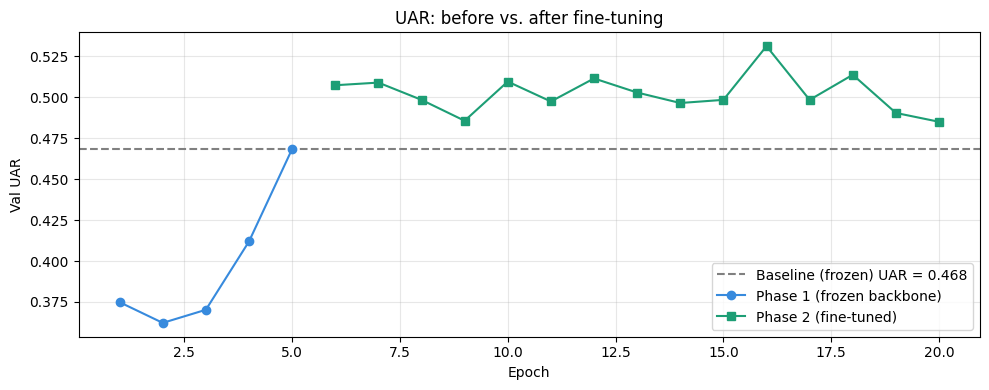

In [ ]:
plt.figure(figsize=(10, 4))
plt.axhline(baseline_uar, linestyle="--", color="gray",
            label=f"Baseline (frozen) UAR = {baseline_uar:.3f}")
all_uar = uar_log_phase1 + uar_log_phase2
x_p1 = range(1, len(uar_log_phase1)+1)
x_p2 = range(len(uar_log_phase1)+1, len(all_uar)+1)
plt.plot(x_p1, uar_log_phase1, "o-", color="#378ADD",
         label="Phase 1 (frozen backbone)")
plt.plot(x_p2, uar_log_phase2, "s-", color="#1D9E75",
         label="Phase 2 (fine-tuned)")
plt.xlabel("Epoch"); plt.ylabel("Val UAR")
plt.title("UAR: before vs. after fine-tuning")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/results/uar_curve.png", dpi=150)
plt.show()

## **6. UAR + docs**

**Final test UAR and full classification report**

In [ ]:
# Load the best saved model
model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
test_uar, test_preds, test_true = evaluate(model, test_loader)

print(f"Final Test UAR: {test_uar:.4f}\n")
print("Per-class breakdown:")
print(classification_report(
    test_true, test_preds,
    target_names=le.classes_,
    digits=4))

Final Test UAR: 0.5666

Per-class breakdown:
              precision    recall  f1-score   support

       angry     0.7619    0.5517    0.6400        29
       happy     0.5862    0.5862    0.5862        29
     neutral     0.7483    0.8527    0.7971       129
         sad     0.4211    0.2759    0.3333        29

    accuracy                         0.6991       216
   macro avg     0.6294    0.5666    0.5892       216
weighted avg     0.6844    0.6991    0.6854       216



**Confusion matrix**

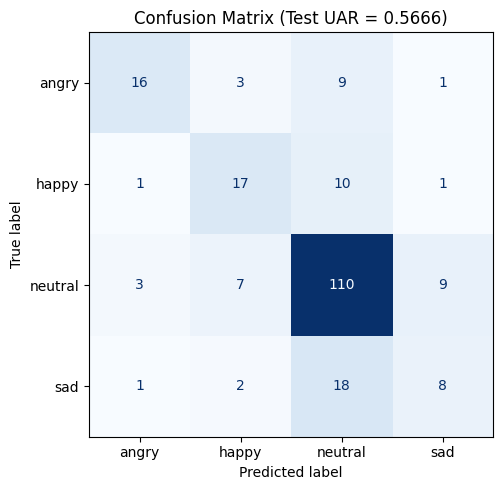

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_true, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix (Test UAR = {test_uar:.4f})")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/results/confusion_matrix.png", dpi=150)
plt.show()

**Document frozen vs. trainable layers (required for report)**

In [ ]:
print("="*65)
print(f"{'LAYER NAME':<45} {'STATUS':<12} {'PARAMS':>8}")
print("="*65)
for name, param in model.named_parameters():
    status = "TRAINABLE" if param.requires_grad else "frozen"
    print(f"{name:<45} {status:<12} {param.numel():>8,}")

total   = sum(p.numel() for p in model.parameters())
trained = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("="*65)
print(f"{'TOTAL':<45} {'':12} {total:>8,}")
print(f"{'TRAINABLE':<45} {'':12} {trained:>8,}  ({100*trained/total:.1f}%)")
print()
print("SUMMARY FOR REPORT")
print("-"*40)
print(f"  Baseline UAR (frozen backbone) : {baseline_uar:.4f}")
print(f"  Fine-tuned UAR (all unfrozen)  : {best_uar:.4f}")
print(f"  Test UAR (best checkpoint)     : {test_uar:.4f}")
print(f"  UAR improvement after tuning   : +{best_uar - baseline_uar:.4f}")

LAYER NAME                                    STATUS         PARAMS
backbone_frozen.0.weight                      TRAINABLE       3,136
backbone_frozen.1.weight                      TRAINABLE          64
backbone_frozen.1.bias                        TRAINABLE          64
backbone_frozen.4.0.conv1.weight              TRAINABLE      36,864
backbone_frozen.4.0.bn1.weight                TRAINABLE          64
backbone_frozen.4.0.bn1.bias                  TRAINABLE          64
backbone_frozen.4.0.conv2.weight              TRAINABLE      36,864
backbone_frozen.4.0.bn2.weight                TRAINABLE          64
backbone_frozen.4.0.bn2.bias                  TRAINABLE          64
backbone_frozen.4.1.conv1.weight              TRAINABLE      36,864
backbone_frozen.4.1.bn1.weight                TRAINABLE          64
backbone_frozen.4.1.bn1.bias                  TRAINABLE          64
backbone_frozen.4.1.conv2.weight              TRAINABLE      36,864
backbone_frozen.4.1.bn2.weight                TR

## **7. Siamese**

**Build the Siamese encoder network**

Shares weights between two branches. Learns "are these two utterances the same emotion?" rather than predicting a class directly.

In [ ]:
class SiameseEncoder(nn.Module):
    def __init__(self, input_dim=64*300, embed_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

    def encode(self, x):
        # x: (B, 1, 64, 300) → flatten → embed
        return self.encoder(x.flatten(1))

    def forward(self, x1, x2):
        e1 = self.encode(x1)
        e2 = self.encode(x2)
        dist = nn.functional.pairwise_distance(e1, e2)
        return dist

def contrastive_loss(dist, same, margin=1.0):
    """
    same=1 → same emotion class → pull embeddings together
    same=0 → different emotion   → push apart
    """
    loss = same * dist.pow(2) + \
           (1 - same) * torch.clamp(margin - dist, min=0).pow(2)
    return loss.mean()

siamese = SiameseEncoder().to(DEVICE)
print("Siamese encoder ready")

Siamese encoder ready


**Create paired dataset for Siamese training**

In [ ]:
class PairDataset(Dataset):
    def __init__(self, features, labels, n_pairs=5000):
        self.X = torch.tensor(features).unsqueeze(1)
        self.y = labels
        self.pairs = []
        # Build balanced pairs: 50% same, 50% different
        for _ in range(n_pairs):
            idx1 = random.randint(0, len(labels)-1)
            same = random.random() > 0.5
            if same:
                # Pick another sample with same label
                candidates = np.where(labels == labels[idx1])[0]
                idx2 = random.choice(candidates)
                pair_label = 1  # same emotion
            else:
                candidates = np.where(labels != labels[idx1])[0]
                idx2 = random.choice(candidates)
                pair_label = 0  # different emotion
            self.pairs.append((idx1, idx2, pair_label))

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        i1, i2, label = self.pairs[idx]
        return self.X[i1], self.X[i2], torch.tensor(label, dtype=torch.float)

pair_ds = PairDataset(X_tr, y_tr, n_pairs=4000)
pair_loader = DataLoader(pair_ds, batch_size=32, shuffle=True)
print(f"Pair dataset: {len(pair_ds)} pairs")

Pair dataset: 4000 pairs


**Train the Siamese network**

In [ ]:
s_optimizer = optim.Adam(siamese.parameters(), lr=1e-3)

for epoch in range(10):
    siamese.train()
    total_loss = 0
    for x1, x2, label in pair_loader:
        x1, x2, label = x1.to(DEVICE), x2.to(DEVICE), label.to(DEVICE)
        s_optimizer.zero_grad()
        dist = siamese(x1, x2)
        loss = contrastive_loss(dist, label)
        loss.backward()
        s_optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/10 | Contrastive Loss: {total_loss/len(pair_loader):.4f}")

torch.save(siamese.state_dict(),
           f"{BASE_DIR}/models/siamese_model.pt")
print("Siamese model saved!")

Epoch 1/10 | Contrastive Loss: 1.7778
Epoch 2/10 | Contrastive Loss: 0.3244
Epoch 3/10 | Contrastive Loss: 0.2885
Epoch 4/10 | Contrastive Loss: 0.2835
Epoch 5/10 | Contrastive Loss: 0.2841
Epoch 6/10 | Contrastive Loss: 0.2812
Epoch 7/10 | Contrastive Loss: 0.2780
Epoch 8/10 | Contrastive Loss: 0.2741
Epoch 9/10 | Contrastive Loss: 0.2640
Epoch 10/10 | Contrastive Loss: 0.2617
Siamese model saved!


**Few-shot classification using Siamese embeddings**

With only 5 labeled examples per class (few-shot), classify test samples by finding the nearest support embedding.

In [ ]:
siamese.eval()

# Build support set: 5 examples per class
support_feats, support_labels = [], []
for cls_id in range(4):
    idxs = np.where(y_tr == cls_id)[0][:5]
    for i in idxs:
        support_feats.append(X_tr[i])
        support_labels.append(cls_id)

sup_X = torch.tensor(np.array(support_feats)).unsqueeze(1).to(DEVICE)
sup_y = np.array(support_labels)

# Compute support embeddings once
with torch.no_grad():
    sup_emb = siamese.encode(sup_X)  # (20, 128)

# Classify each test sample
test_X_t = torch.tensor(X_te).unsqueeze(1).to(DEVICE)
preds = []
with torch.no_grad():
    for i in range(len(X_te)):
        q_emb = siamese.encode(test_X_t[i:i+1])
        dists = nn.functional.pairwise_distance(
            q_emb.expand(len(sup_emb), -1), sup_emb)
        pred = sup_y[dists.cpu().argmin().item()]
        preds.append(pred)

few_shot_uar = recall_score(y_te, preds, average="macro")
print(f"5-shot UAR (Siamese): {few_shot_uar:.4f}")
print(classification_report(y_te, preds,
      target_names=le.classes_, digits=4))

5-shot UAR (Siamese): 0.3370
              precision    recall  f1-score   support

       angry     0.1930    0.3793    0.2558        29
       happy     0.1750    0.2414    0.2029        29
     neutral     0.6792    0.2791    0.3956       129
         sad     0.1970    0.4483    0.2737        29

    accuracy                         0.3102       216
   macro avg     0.3110    0.3370    0.2820       216
weighted avg     0.4815    0.3102    0.3346       216



**Check Check Check**

In [ ]:
import os

checks = {
    "GPU active"         : torch.cuda.is_available(),
    "DataFrame loaded"   : 'df' in dir() and len(df) > 0,
    "Features extracted" : 'feats_norm' in dir() and feats_norm.shape[0] > 0,
    "Label encoder ready": 'le' in dir() and len(le.classes_) == 4,
    "CNN model trained"  : 'best_uar' in dir() and best_uar > 0,
    "Test UAR computed"  : 'test_uar' in dir() and test_uar > 0,
    "Baseline UAR logged": 'baseline_uar' in dir() and baseline_uar > 0,
    "Model saved"        : os.path.exists(f"{BASE_DIR}/models/best_model.pt"),
    "UAR curve saved"    : os.path.exists(f"{BASE_DIR}/results/uar_curve.png"),
    "Confusion matrix"   : os.path.exists(f"{BASE_DIR}/results/confusion_matrix.png"),
    "Siamese trained"    : os.path.exists(f"{BASE_DIR}/models/siamese_model.pt"),
}

print("=" * 45)
print(f"  {'CHECKPOINT':<30} STATUS")
print("=" * 45)
for k, v in checks.items():
    status = "DONE" if v else "MISSING"
    icon   = "✓" if v else "✗"
    print(f"  {icon}  {k:<30} {status}")
print("=" * 45)

done  = sum(checks.values())
total = len(checks)
print(f"\n  {done}/{total} checkpoints complete")

  CHECKPOINT                     STATUS
  ✓  GPU active                     DONE
  ✓  DataFrame loaded               DONE
  ✓  Features extracted             DONE
  ✓  Label encoder ready            DONE
  ✓  CNN model trained              DONE
  ✓  Test UAR computed              DONE
  ✓  Baseline UAR logged            DONE
  ✓  Model saved                    DONE
  ✓  UAR curve saved                DONE
  ✓  Confusion matrix               DONE
  ✓  Siamese trained                DONE

  11/11 checkpoints complete
